Train shape: (399, 3000), Label: (399,)
Test shape: (319, 3000), Label: (319,)
正在生成小波时频图...
Epoch 1/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 366ms/step - accuracy: 0.5141 - loss: 0.9279 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - accuracy: 0.4984 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 402ms/step - accuracy: 0.5110 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 439ms/step - accuracy: 0.5580 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 433ms/step - accuracy: 0.5047 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 432ms/step - accuracy: 0.4922 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/12
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 428ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/12


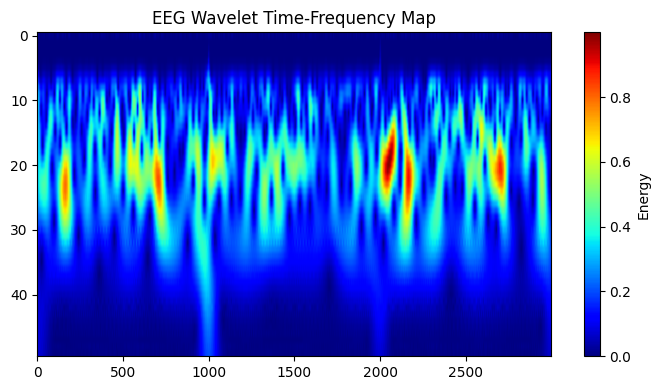

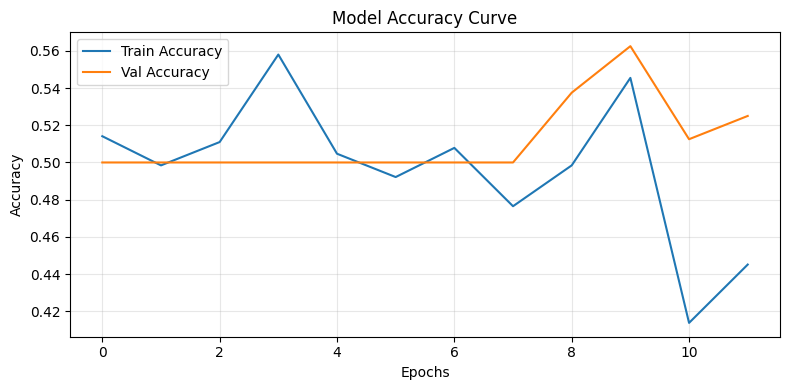

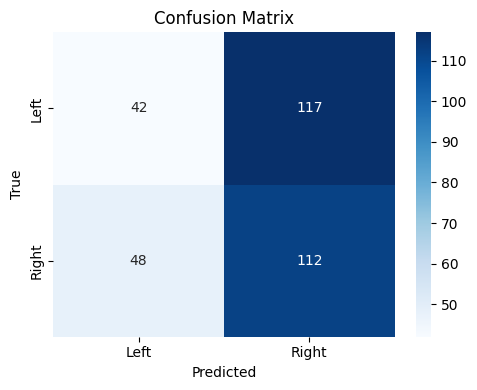


Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.47      0.26      0.34       159
  Right Hand       0.49      0.70      0.58       160

    accuracy                           0.48       319
   macro avg       0.48      0.48      0.46       319
weighted avg       0.48      0.48      0.46       319



In [16]:

import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import confusion_matrix, classification_report

# 解决字体警告
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

path = r"C:\Users\28062\Desktop\实验\lab5"

X_train = pd.read_csv(f"{path}/MI-EEG-B9T.csv").values
y_train = pd.read_csv(f"{path}/2class_MI_EEG_train_9.csv", header=None).values.ravel()

X_test = pd.read_csv(f"{path}/MI-EEG-B9E.csv").values
y_test = pd.read_csv(f"{path}/2class_MI_EEG_test_9.csv", header=None).values.ravel()

# 修复样本数不匹配
def align_data(x, y):
    min_len = min(len(x), len(y))
    return x[:min_len], y[:min_len]

X_train, y_train = align_data(X_train, y_train)
X_test, y_test = align_data(X_test, y_test)

print(f"Train shape: {X_train.shape}, Label: {y_train.shape}")
print(f"Test shape: {X_test.shape}, Label: {y_test.shape}")

def wavelet_to_image(signal):
    scales = np.arange(1, 51)
    coeff, _ = pywt.cwt(signal, scales, 'cmor1.5-1.0')
    img = np.abs(coeff)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return np.expand_dims(img, axis=-1)

print("正在生成小波时频图...")
X_train_img = np.array([wavelet_to_image(s) for s in X_train])
X_test_img = np.array([wavelet_to_image(s) for s in X_test])

model = Sequential([
    Input(shape=X_train_img.shape[1:]),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


history = model.fit(
    X_train_img, y_train,
    epochs=12,
    batch_size=16,
    validation_split=0.2
)

loss, acc = model.evaluate(X_test_img, y_test, verbose=0)
print(f"\n测试集准确率: {acc:.4f}")

# 预测
y_pred_prob = model.predict(X_test_img, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# 图1：小波时频图
plt.figure(figsize=(7,4))
plt.imshow(X_train_img[0,:,:,0], cmap="jet", aspect="auto")
plt.title("EEG Wavelet Time-Frequency Map")
plt.colorbar(label="Energy")
plt.tight_layout()
plt.show()

# 图2：训练 & 验证准确率曲线
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 图3：混淆矩阵
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Left","Right"],
            yticklabels=["Left","Right"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Left Hand","Right Hand"]))